# Module 3.2: The Decoder Layer (The Writer)

In the previous module, we built the **Encoder**, which is essentially a "Reader". It reads an entire sentence at once in massive parallel matrix operations to build a deep understanding of the context.

Now we build the **Decoder**, the "Writer". The Decoder takes the context from the Encoder and writes out a response (like translating French to English, or ChatGPT generating an answer). But writing is fundamentally different from reading: you can only write one word at a time, and you cannot look into the future.

## 1. The Generation Problem (Autoregressive)

### The Concept
A Decoder is "autoregressive". This means it predicts word 1, feeds word 1 back into itself to predict word 2, feeds words 1 & 2 back to predict word 3, and so on. 

### Why do we need a new layer? (The Cheating Problem)
During training, we give neural networks the *entire* correct answer paragraph right away for insane mathematical speed. But if we let a Decoder use standard Attention (where every word looks at every other word), the first word being generated would simultaneously "look" at the words coming after it in the training data! 
The model would "cheat" by looking into the future, guaranteeing it gets the answers right in training, but utterly failing when you actually try to talk to it in the real world.

## 2. Causal Masked Attention (The Blinder)

### The Analogy (The Test Paper)
Imagine taking a test where the answers are printed on the right side of the page. To test yourself honestly, you slide a piece of paper down line-by-line, covering everything below where you are reading. You can see the past, but the future is "blacked out."

### The Math
Before we run the Softmax function, we force the Attention Scores of all "future" words to negative infinity (`-inf`). Mathematically, $e^{-\infty} = 0$. When those scores hit the Softmax exponent, their percentage drops to exactly `0.0%` probability. They vanish from the context sum.
We do this using a lower-triangular matrix, known in PyTorch as `torch.tril`.

### Why do we need it?
Mathematically enforcing a sequence direction allows us to feed thousands of words into the matrix simultaneously during training, fully unlocking the GPU's parallel processing speed, while enforcing the strict rule that words can only ever look backwards, never forwards.

1.0 means 'I can look here'. 0.0 means 'MASKED!'
tensor([[1., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0.],
        [1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1.]])


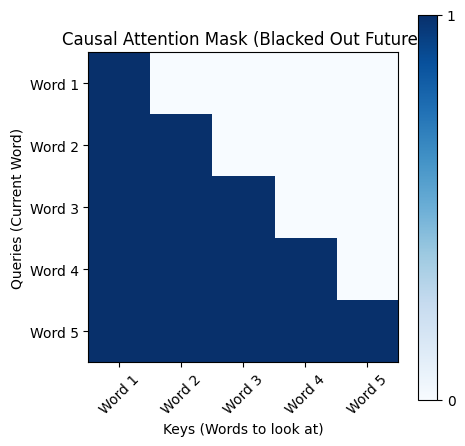

In [1]:
import torch
import matplotlib.pyplot as plt

# Imagine a sentence with 5 words. We want to build a mask for it.
seq_len = 5

# Create a mask of 1s (True) in the lower triangle, and 0s (False) in the upper triangle
subsequent_mask = torch.tril(torch.ones(seq_len, seq_len))

print("1.0 means 'I can look here'. 0.0 means 'MASKED!'")
print(subsequent_mask)

# Visualizing the Mask
plt.figure(figsize=(5,5))
plt.imshow(subsequent_mask.numpy(), cmap='Blues')
plt.title('Causal Attention Mask (Blacked Out Future)')
plt.xlabel('Keys (Words to look at)')
plt.ylabel('Queries (Current Word)')
plt.xticks(range(5), ['Word 1', 'Word 2', 'Word 3', 'Word 4', 'Word 5'], rotation=45)
plt.yticks(range(5), ['Word 1', 'Word 2', 'Word 3', 'Word 4', 'Word 5'])
plt.colorbar(ticks=[0, 1])
plt.show()

## 3. Cross-Attention (The Translator)

### The Concept
Now our Decoder is blindly generating text strictly based on the previous words it just wrote. But wait... how does it know what it's supposed to be writing about? If it's translating French (Encoder) to English (Decoder), how do they communicate?

### The Analogy (The Detective)
Imagine a Detective (the Decoder) trying to write a case report. They know what they are writing right now (the **Query**), but they need to pull facts from the massive library of evidence gathered earlier by the Police (the Encoder's final **Keys** and **Values**).

### Why do we need it?
Cross-attention bridges the two networks. 
- The `Query (Q)` matrix is generated directly from the Decoder's own self-attention output.
- The `Key (K)` and `Value (V)` matrices are piped in directly from the final output of the Encoder.
This allows the English word that is currently being typed to dynamically "sweep" over the entire French sentence to find the relevant context before it prints!

## 4. Building the Full Decoder Block

### The Concept
The Decoder is just an Encoder Block with one extra layer squeezed into the middle.

1. **Masked Self-Attention**: It looks at what it has written so far.
2. **Cross-Attention**: It queries the Encoder for relevant translation details.
3. **Feed-Forward**: It processes this combined information.

In [2]:
import torch.nn as nn
import sys, os
sys.path.append(os.path.abspath("../"))
from src.functional import scaled_dot_product_attention

# Note: In a full pipeline, we would import RMSNorm and FeedForward from Notebooks 5 and 6.
# For visual demonstration, we use PyTorch's native mockups.

class MockMultiHeadAttention(nn.Module):
    def __init__(self, d_model): super().__init__(); self.proj = nn.Linear(d_model, d_model)
    def forward(self, q, k, v, mask=None): return self.proj(q)

class DecoderBlock(nn.Module):
    def __init__(self, d_model: int, num_heads: int, hidden_dim: int):
        super().__init__()
        
        # 1. Masked Self-Attention (Look only at the past)
        self.masked_self_attention = MockMultiHeadAttention(d_model)
        self.norm1 = nn.LayerNorm(d_model)
        
        # 2. Cross-Attention (Look at the Encoder)
        self.cross_attention = MockMultiHeadAttention(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        # 3. Memory Processor
        self.ffn = nn.Sequential(nn.Linear(d_model, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, d_model))
        self.norm3 = nn.LayerNorm(d_model)

    def forward(self, x, encoder_output, causal_mask):
        # Step 1: Pre-Norm Masked Self-Attention! (Q, K, V are all from 'x')
        norm_x = self.norm1(x)
        x = x + self.masked_self_attention(norm_x, norm_x, norm_x, mask=causal_mask)
        
        # Step 2: CROSS-ATTENTION! (Q is from Decoder. K and V are from Encoder)
        norm_x2 = self.norm2(x)
        x = x + self.cross_attention(q=norm_x2, k=encoder_output, v=encoder_output)
        
        # Step 3: FFN (Thinker)
        x = x + self.ffn(self.norm3(x))
        
        return x

# Let's Test It Out!
d_model = 128
# Pretend the Encoder processed a 10-word French sentence.
encoder_french_output = torch.randn(1, 10, d_model)
# Pretend the Decoder has generated 3 English words so far.
decoder_english_input = torch.randn(1, 3, d_model)

# Mask to stop the Decoder from cheating (3x3 for the 3 generated words)
causal_mask = torch.tril(torch.ones(3, 3))

# Instantiate the Block
decoder = DecoderBlock(d_model=d_model, num_heads=8, hidden_dim=512)

# Forward Pass!
output = decoder(decoder_english_input, encoder_french_output, causal_mask)
print(f"Decoder Input length: {decoder_english_input.shape}")
print(f"Encoder Input length: {encoder_french_output.shape}")
print(f"Final Output length:  {output.shape} -> (Batch, Seq_Len_English, Embed_Dim)")

Decoder Input length: torch.Size([1, 3, 128])
Encoder Input length: torch.Size([1, 10, 128])
Final Output length:  torch.Size([1, 3, 128]) -> (Batch, Seq_Len_English, Embed_Dim)
